# Random Forest for Arrival Delay Prediction

Research question: Which operational and scheduling factors contribute most strongly to airline arrival delays?

## Problem Statement

- Mục tiêu: huấn luyện `RandomForestRegressor` để dự đoán `ArrDelay`.
- So sánh kết quả với `LinearRegression`.
- Tập trung vào feature importance để hiểu yếu tố vận hành và lịch trình tác động như thế nào.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

data_path = Path('..') / 'data' / 'processed_flight_data.csv'
image_path = Path('..') / 'images'
model_path = Path('..') / 'models'

image_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    raise FileNotFoundError(f'Dataset not found: {data_path}. Please add processed_flight_data.csv to the data folder.')

df = pd.read_csv(data_path)
print('Loaded dataset:', data_path)
print('Dataset shape:', df.shape)

Loaded dataset: ..\data\processed_flight_data.csv
Dataset shape: (1868454, 45)


## Data Loading

- Kiểm tra cấu trúc dữ liệu và các cột có sẵn.
- Đây là bước đầu để chọn feature vận hành và lịch trình phù hợp.

In [2]:
print(df.head(5).to_string(index=False))
print('Selected columns:', len(df.columns))
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head(10))


 Unnamed: 0  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  CRSElapsedTime  ArrDelay  DepDelay Origin Dest  Distance  TaxiIn  TaxiOut CancellationCode  CarrierDelay  WeatherDelay  NASDelay  SecurityDelay  LateAircraftDelay  UniqueCarrier_AA  UniqueCarrier_AQ  UniqueCarrier_AS  UniqueCarrier_B6  UniqueCarrier_CO  UniqueCarrier_DL  UniqueCarrier_EV  UniqueCarrier_F9  UniqueCarrier_FL  UniqueCarrier_HA  UniqueCarrier_MQ  UniqueCarrier_NW  UniqueCarrier_OH  UniqueCarrier_OO  UniqueCarrier_UA  UniqueCarrier_US  UniqueCarrier_WN  UniqueCarrier_XE  UniqueCarrier_YV  Origin_Freq  Dest_Freq  DepHour  IsWeekend  IsRushHour FlightPeriod
          0      1           3          4   2003.0   2211.0           150.0     -14.0       8.0    IAD  TPA       810     4.0      8.0                N           NaN           NaN       NaN            NaN                NaN                 0                 0                 0                 0                 0                 0                 0                

## Exploratory Data Analysis

- Phân tích phân phối `ArrDelay`.
- Kiểm tra xem dữ liệu có outlier và skewness hay không.

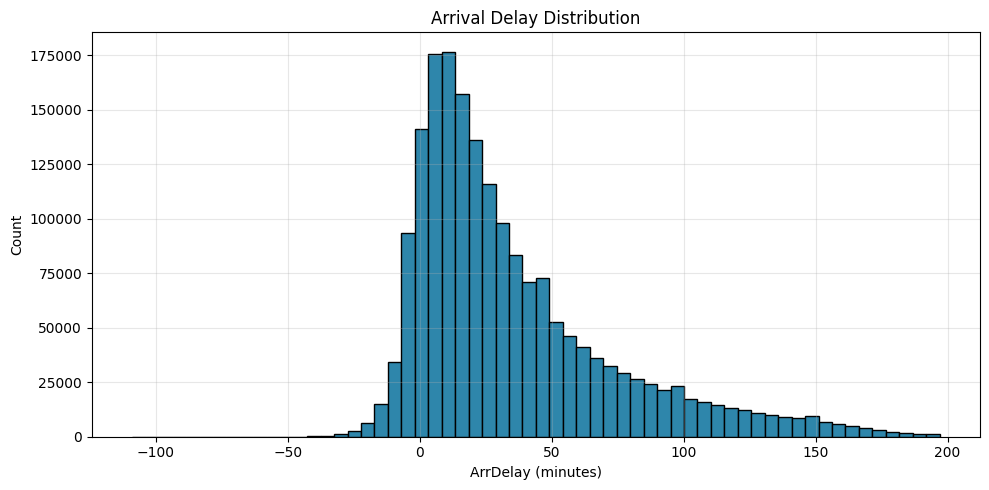

Saved plot to ..\images\rf_arrdelay_distribution.png
Mean ArrDelay: 35.4356302055068
Median ArrDelay: 23.0
Skewness: 1.420221398764318
Outliers > 60 min: 0.2029806460314249


In [3]:
if 'ArrDelay' not in df.columns:
    raise ValueError('Target column ArrDelay is not present in the dataset.')

arr_delay = df['ArrDelay'].dropna()
plt.figure(figsize=(10, 5))
plt.hist(arr_delay, bins=60, color='#2E86AB', edgecolor='black')
plt.title('Arrival Delay Distribution')
plt.xlabel('ArrDelay (minutes)')
plt.ylabel('Count')
plt.grid(alpha=0.3)
dist_path = image_path / 'rf_arrdelay_distribution.png'
plt.tight_layout()
plt.savefig(dist_path, dpi=200)
plt.show()
print('Saved plot to', dist_path)
print('Mean ArrDelay:', arr_delay.mean())
print('Median ArrDelay:', arr_delay.median())
print('Skewness:', arr_delay.skew())
print('Outliers > 60 min:', (arr_delay > 60).mean())

### Interpretation

- Dữ liệu delay thường có phân phối lệch phải.
- Random Forest có thể xử lý tốt hơn các quan hệ phi tuyến và outlier so với Linear Regression.

## Feature Selection

- Chọn các yếu tố hoạt động và lịch trình được kỳ vọng ảnh hưởng tới độ trễ.
- Nếu dataset đã sẵn sàng, ta sử dụng các cột tương tự như `DepDelay`, `CRSElapsedTime`, `Distance`, `DepHour`, `IsWeekend`, `IsRushHour`, `Origin_Freq`, `Dest_Freq`, `Month`, `DayOfWeek`.

In [6]:
selected_features = [
    'DepDelay',
    'CRSElapsedTime',
    'Distance',
    'DepHour',
    'IsWeekend',
    'IsRushHour',
    'Origin_Freq',
    'Dest_Freq',
    'Month',
    'DayOfWeek'
]
target_column = 'ArrDelay'

missing_features = [col for col in selected_features + [target_column] if col not in df.columns]
if missing_features:
    raise ValueError(f'Missing required columns: {missing_features}')

model_df = df[selected_features + [target_column]].dropna()
print('Model dataset shape after dropna:', model_df.shape)
print('Selected features:', selected_features)

Model dataset shape after dropna: (1868454, 11)
Selected features: ['DepDelay', 'CRSElapsedTime', 'Distance', 'DepHour', 'IsWeekend', 'IsRushHour', 'Origin_Freq', 'Dest_Freq', 'Month', 'DayOfWeek']


## Train/Test Split

- Chia dữ liệu để giữ phần test độc lập.
- Dùng `random_state=42` để tái tạo kết quả.

In [ ]:
model_df = df[selected_features + [target_column]].dropna()
X = model_df[selected_features]
y = model_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

NameError: name 'model_df' is not defined

## Feature Scaling

- Random Forest không yêu cầu scaling vì nó dựa trên cây quyết định.
- Tuy nhiên, ta vẫn chuẩn hóa cho Linear Regression so sánh.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaled features for Linear Regression only.')

## Reusable Functions

- Tách hàm đánh giá và trực quan để giữ notebook sạch và dễ đọc.

In [ ]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    print(f'{name} metrics: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f}')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

def plot_predictions(y_true, y_pred, filename, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.4, s=14)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2)
    plt.xlabel('Actual ArrDelay')
    plt.ylabel('Predicted ArrDelay')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    path = image_path / filename
    plt.savefig(path, dpi=200)
    plt.show()
    print('Saved plot to', path)

def plot_feature_importance(features, importances, filename):
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'], importance_df['importance'], color='#4C72B0')
    plt.gca().invert_yaxis()
    plt.xlabel('Feature Importance')
    plt.title('Random Forest Feature Importances')
    plt.tight_layout()
    path = image_path / filename
    plt.savefig(path, dpi=200)
    plt.show()
    print('Saved plot to', path)
    return importance_df

def save_metrics(metrics, filename):
    df_metrics = pd.DataFrame(metrics)
    path = model_path / filename
    df_metrics.to_csv(path, index=False)
    print('Saved metrics to', path)
    return df_metrics

## Model Training

- Huấn luyện `RandomForestRegressor` trên dữ liệu train.
- Sử dụng `random_state=42` để đảm bảo reproducibility.

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print('Random Forest model training completed.')

## Evaluation

- So sánh `RandomForestRegressor` với `LinearRegression`.
- Dùng MAE, RMSE và R².

In [ ]:
rf_pred = rf_model.predict(X_test)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

rf_metrics = evaluate_model('Random Forest', y_test, rf_pred)
lr_metrics = evaluate_model('Linear Regression', y_test, lr_pred)

metrics_df = save_metrics([rf_metrics, lr_metrics], 'random_forest_metrics.csv')
metrics_df

## Comparison with Linear Regression

- Nếu Random Forest có RMSE thấp hơn, điều đó cho thấy mô hình phi tuyến đang nắm bắt đặc tính phức tạp tốt hơn.
- Nếu R² cao hơn, mô hình giải thích biến thiên tốt hơn.

In [ ]:
plot_predictions(y_test, rf_pred, 'rf_actual_vs_predicted.png', 'Random Forest: Actual vs Predicted')
plot_predictions(y_test, lr_pred, 'lr_actual_vs_predicted.png', 'Linear Regression: Actual vs Predicted')

## Feature Importance

- Hiển thị các yếu tố đóng góp mạnh nhất vào dự đoán độ trễ.
- Đối với Random Forest, importance dựa trên giảm impurity qua các split trong cây.

In [ ]:
importance_df = plot_feature_importance(selected_features, rf_model.feature_importances_, 'rf_feature_importance.png')
importance_df

### Interpretation of Feature Importance

- Các feature có importance cao cho thấy chúng đóng vai trò quyết định trong quá trình phân loại các split và dự đoán delay.
- Ví dụ: `DepDelay` là một chỉ số vận hành trực tiếp và mạnh về việc dự đoán delay đến.
- Các feature lịch trình như `DepHour` và `IsRushHour` phản ánh áp lực giờ cao điểm và có thể liên quan đến sự chậm trễ do tắc nghẽn.

## Why Random Forest is Appropriate

- Random Forest xử lý tốt các mối quan hệ phi tuyến và tương tác giữa feature.
- Flight delay prediction thường liên quan đến nhiều yếu tố vận hành và lịch trình không tuyến tính.
- Không giống Linear Regression, Random Forest không yêu cầu giả định về mối quan hệ tuyến tính giữa feature và target.

## Saving the Model

- Lưu mô hình đã huấn luyện và metrics để sử dụng lại.

In [ ]:
model_file = model_path / 'random_forest_arrdelay.pkl'
with open(model_file, 'wb') as f:
    pickle.dump({'model': rf_model, 'features': selected_features}, f)

print('Saved Random Forest model to', model_file)

## Operational Meaning

- Feature importance giúp xác định yếu tố nào cần ưu tiên khi tối ưu lịch trình và vận hành.
- Nếu `DepDelay` và `DepHour` đứng đầu, điều đó cho thấy chú trọng cải thiện thời gian cất cánh và quản lý giờ cao điểm có thể giảm delay.
- Các yếu tố như `Origin_Freq` và `Dest_Freq` thể hiện tác động của tần suất sân bay và lưu lượng chuyến bay.

## Summary

- Random Forest có thể cung cấp dự đoán chính xác hơn và giải thích tốt hơn trong trường hợp dữ liệu phi tuyến.
- Linear Regression là baseline hữu ích, nhưng flight delay prediction thường cần các mô hình phức tạp hơn.